# Salary Prediction

Corresponding  with this notebook is a slide deck where you will need to update all the portions in red.  Completing the notebook will provide all the results needed for the slides.  **Correctly completing the slides is a required part of the project.**


## Table of Contents
- [Introduction](#intro)
- [Part I - Descriptive Statistics](#descriptive)
- [Part II - Regression](#regression)
- [Part III - Interpret Results](#interpret)


<a id='intro'></a>
### Introduction

Linear Regression is very commonly performed by data analysts and data scientists.  For this project, you will be working to understand the results of a Linear Regression model associated with salaries.  Your goal is to work through this notebook to understand what variables are related to salary, and how exactly they are related.

As a final check, assure you meet all the criteria on the rubric.

<a id='descriptive'></a>
#### Part I - Descriptive Statistics

To get started, let's import our libraries.

In [3]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
random.seed(0)

`1.a)` Now, read in the `salary_data.csv` data. Store it in `df`. Read in the dataset and take a look at the top few rows here.

In [5]:
df = pd.read_csv('../data/salary_data.csv')
df.head()


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [288]:
rename = {'Age': 'age', 'Gender': 'gender', 'Education Level': 'education_level', 'Job Title': 'job_title', 'Years of Experience': 'years_of_experience', 'Salary': 'salary'}

df.rename(columns=rename, inplace=True)
df.head()

,age,gender,education_level,job_title,years_of_experience,salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


`b)` Use the below cell to find the number of rows in the dataset.

- columns: 6
- rows: 375

In [289]:
df.shape

(375, 6)

`c)` Do any of the rows have missing values? 

If there are missing values, determine a method for dealing with them.


Every column has at least two missing values. Since there are so few missing values in the dataset, they will be dropped.

In [290]:
# check data types and missing values
df.info()

# count total missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  373 non-null    float64
 1   gender               373 non-null    str    
 2   education_level      373 non-null    str    
 3   job_title            373 non-null    str    
 4   years_of_experience  373 non-null    float64
 5   salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.7 KB

Missing values: 12


In [291]:
# drop nulls
df = df.dropna()

`d)` How many employees are in each `Education Level`? Build a bar chart to show the count of employees in each level.

- 224 employees have a bachelor's.
- 98 employees have a master's.
- 51 employees have a PhD.

In [292]:
df['education_level'].value_counts()

education_level
Bachelor's    224
Master's       98
PhD            51
Name: count, dtype: int64

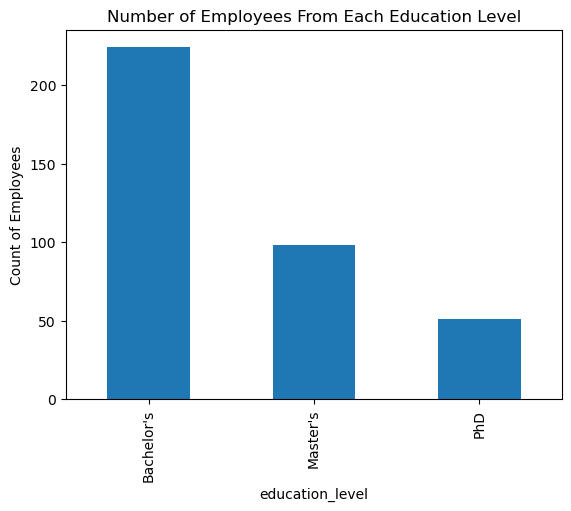

In [293]:
df['education_level'].value_counts().plot(kind='bar');
plt.title('Number of Employees From Each Education Level');
plt.ylabel('Count of Employees');
plt.show();

`e)` What are the possible values for `Salary`?  What does the distribution of `Salary` look like?

There are 36 unique values for `Salary`. The smallest value is \$350 and the largest value is \$250,000. The value of \$350 is likely an error and will be dropped from the dataset.

`Salary` distribution is multimodal. Salaries seem to cluster around certain numbers, with the largest peak in the \$40-50k bin, and a second large peak around \$95k. The graph shows a steep decline in the number of salaries at around \$190k. The data also has a slight right skew.

In [294]:
num_salaries = df['salary'].nunique()

print(f"Number of unique values: {num_salaries}")

# distribution
df['salary'].describe()


Number of unique values: 36


count       373.000000
mean     100577.345845
std       48240.013482
min         350.000000
25%       55000.000000
50%       95000.000000
75%      140000.000000
max      250000.000000
Name: salary, dtype: float64

In [295]:
# drop likely error
df = df[df['salary'] != 350.0]

df.salary.describe()

count       372.000000
mean     100846.774194
std       48023.137565
min       30000.000000
25%       55000.000000
50%       95000.000000
75%      140000.000000
max      250000.000000
Name: salary, dtype: float64

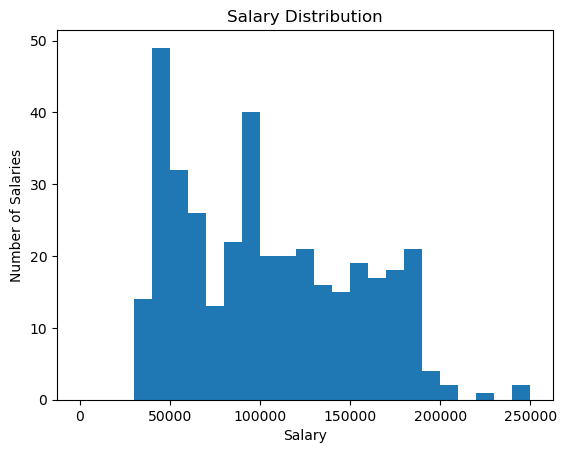

In [296]:
# Chart of salaries
df['salary'].plot(kind='hist', bins=range(0, 260000, 10000));
plt.title('Salary Distribution');
plt.xlabel('Salary');
plt.ylabel('Number of Salaries');
plt.show();

<a id='regression'></a>
#### Part II - Regression

`1.` Now that you have had a chance to learn more about the dataset, let's look more at how different factors are related to `Salary`.

`a)` Consider average salary by gender, is there evidence that salaries are higher for one gender over the other?

Yes. There is evidence that male salaries are higher than female salaries. The average salary for men is around 8% higher than for women. The median salary for men is around 11% higher than it is for women.

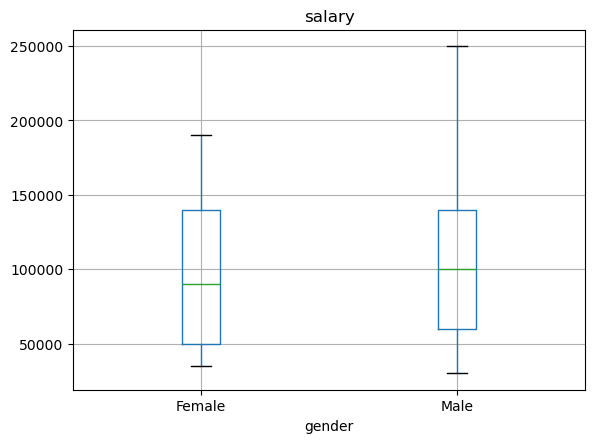

,mean,median,count
gender,,,
Female,97011.173184,90000.0,179
Male,104404.145078,100000.0,193


In [297]:
df.boxplot(column='salary', by='gender')
plt.suptitle('')
plt.show()
df.groupby('gender')['salary'].agg(['mean', 'median', 'count'])


`b)` Consider average salary by education level, is there evidence that salaries are higher for increased education?

Yes, there is evidence that salaries are higher for increased education. The median salary for a master's degree is about 85% higher than for a bachelor's degree. The median salary for a doctorate is about 138% higher than for a bachelor's degree, and about 29% higher than for a master's degree.

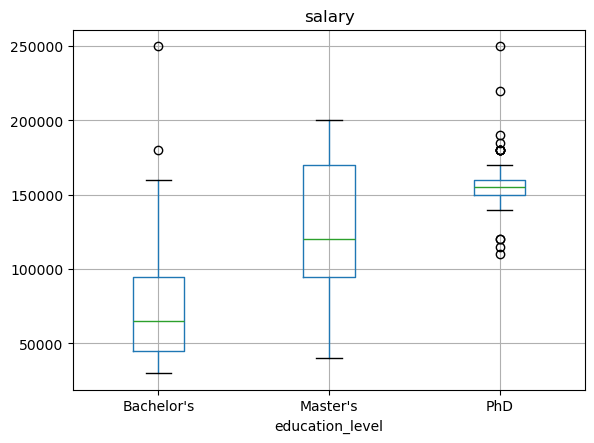

,mean,median,count
education_level,,,
Bachelor's,75089.686099,65000.0,223
Master's,129795.918367,120000.0,98
PhD,157843.137255,155000.0,51


In [298]:
df.boxplot(column='salary', by='education_level')
plt.suptitle('')
plt.show()
df.groupby('education_level')['salary'].agg(['mean', 'median', 'count'])

`c)` Consider average salary by years of experience, is there evidence that salaries are associated with increased years of experience?

Yes, there is evidence that salaries are associated with increased years of experience. A correlation of 0.93 indicates a strong, positive correlation. The scatterplot also shows that salaries grow along with years of experience.

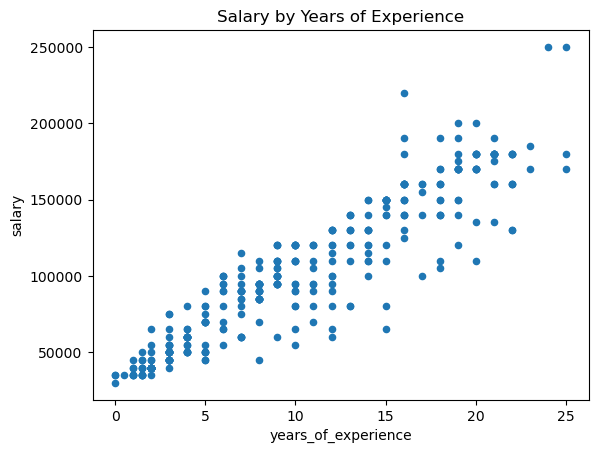

np.float64(0.9305944049090036)

In [299]:
df.plot(kind='scatter', x='years_of_experience', y='salary')
plt.title('Salary by Years of Experience')
plt.show()
df['years_of_experience'].corr(df['salary'])

`d)`  To make use of Job Title column lets create bool flag based on word existiance


List of words:

* Director
* Junior
* Senior
* Manager
* Analyst
* Engineer

In [300]:
flag_words = ['director', 'junior', 'senior', 'manager', 'analyst', 'engineer']
df['job_title'] = df['job_title'].str.lower()

for word in flag_words:
    df['is_' + word] = df['job_title'].str.contains(word).astype(int)
    
df = df.drop('job_title', axis=1)

`e)` Create a flag for gender where 1 is if a person is male and 0 if the person is not.

In [301]:
df['gender_flag'] = (df['gender'] == 'Male').astype(int)

df.info()

<class 'pandas.DataFrame'>
Index: 372 entries, 0 to 374
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  372 non-null    float64
 1   gender               372 non-null    str    
 2   education_level      372 non-null    str    
 3   years_of_experience  372 non-null    float64
 4   salary               372 non-null    float64
 5   is_director          372 non-null    int64  
 6   is_junior            372 non-null    int64  
 7   is_senior            372 non-null    int64  
 8   is_manager           372 non-null    int64  
 9   is_analyst           372 non-null    int64  
 10  is_engineer          372 non-null    int64  
 11  gender_flag          372 non-null    int64  
dtypes: float64(3), int64(7), str(2)
memory usage: 37.8 KB


`f)` Use statsmodels to fit a linear model to predict salary using each of the features from `a-e`.  These include:
* Gender
* Job TItle
* Years of Experience
* Education

In [302]:
import statsmodels.api as sm 

# education dummies
edu = pd.get_dummies(df['education_level'], drop_first=True, dtype=int)
df = df.join(edu)

y = df['salary']
X = df.drop(columns=['gender', 'education_level', 'salary', 'age'])
X = sm.add_constant(X)

# Fit OLS
model_init = sm.OLS(y, X).fit()
print(model_init.summary())


                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     396.3
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          7.55e-188
Time:                        11:59:05   Log-Likelihood:                -4075.5
No. Observations:                 372   AIC:                             8173.
Df Residuals:                     361   BIC:                             8216.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  3.2e+04   2

<a id='interpretation'></a>
### Part III - Interpret Results

`1.` Consider you are tasked with finding which features in your linear model are significantly related to salary.  Were there any features that were not significantly related to salary in your first model?  If not, remove those features and fit a new model.  Only keep the features that were significant from the original model.

The initial model has an $R^2$ value of 0.917, meaning the selected predictors explain about 92% of the variability in salary. The remaining 8% is driven by factors not in the model. The F-statistic is 396.3 with a p-value of essentially zero, which tells us the model as a whole is statistically significant. `is_junior` has a p-value of 0.089. `is_analyst` has a p-value of 0.846. `is_engineer` has a p-value of 0.501. Since these three predictors all have p-values greater than .05, they are not statistically significant. That means we can't reject the null hypothesis with those variables. We should remove them from the model.

In [303]:
X_sig = X.drop(columns=['is_junior', 'is_analyst', 'is_engineer'])

model_sig = sm.OLS(y, X_sig).fit()
print(model_sig.summary())


                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     564.9
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          3.42e-191
Time:                        11:59:05   Log-Likelihood:                -4077.2
No. Observations:                 372   AIC:                             8170.
Df Residuals:                     364   BIC:                             8202.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                2.907e+04   1

`a)` With each additional year of experience, what is the expected change in salary?  What is the 95% confidence interval of the change?

For each additional year of experience, the expected change in salary is \$5,081.26 holding all else constant. I am 95% confident that the true increase per year is between \$4,736.53 and \$5,425.98. 

In [304]:
print(model_sig.params['years_of_experience'])
# confidence intervals
print(model_sig.conf_int(alpha=0.05))

5081.255524896675
                                0             1
const                25802.812489  32333.936827
years_of_experience   4736.533070   5425.977979
is_director          18244.708819  31860.279619
is_senior            10807.291356  17883.915900
is_manager             632.341554   7717.548905
gender_flag           4965.796119  10731.877921
Master's             10023.421230  17921.950579
PhD                  17771.817060  28502.259409


`b)` What is the expected difference in salary between someone with a senior title and someone with none of the other title indications?

Holding all else constant, someone with a senior title is expected to earn \$14,345.60 more than someone with none of the other title flags.

In [305]:
model_sig.params['is_senior']

np.float64(14345.60362783094)

`c)` What is the expected difference in salary between someone with a PhD and an individual with no PhD nor master's degree?  What is the 95% confidence interval of the change?

Holding all else constant, a person with a PhD is expected to make \$23,137.04 more than an individual with neither a PhD nor Master's degree. I am 95% confident that the true difference compared to a Bachelor's degree is between \$17,771.82 and \$28,502.26.

In [306]:
print(model_sig.params["PhD"])
print(model_sig.conf_int().loc['PhD'])

23137.038234214306
0    17771.817060
1    28502.259409
Name: PhD, dtype: float64


`d)` If a male employee has 5 years of experience as a senior engineer with a bachelor's degree, what is the expected salary of the employee?

The expected salary of a male senior engineer with 5 years of experience and a bachelor's degree is \$76,669.09.

In [307]:
person = pd.DataFrame([[1, 5, 0, 1, 0, 1, 0, 0]], columns=X_sig.columns)
person_pred = model_sig.predict(person)
print(person_pred)

0    76669.09293
dtype: float64


`e)` Imagine that the employee in question `d)` actually has a salary of $110,000, what would the residual be for this employee?

The residual would be the observed value minus the predicted value. \$110,000 - \$76,669.09 = \$33,330.91. A positive residual means this employee is earning \$33,330.91 more than the model predicted for someone with their profile.

`f)` How well do you think your model fits?  What metrics or plots would you consider to understand if this model does a good job of predicting salary?

RMSE: 13923.623575296857


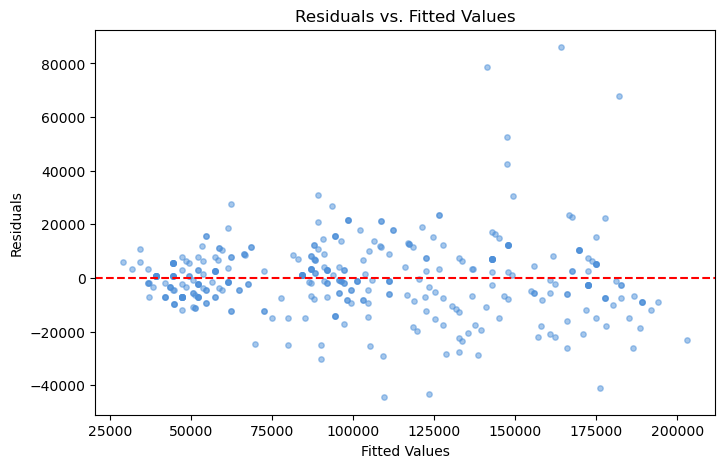

In [308]:
from statsmodels.tools.eval_measures import rmse

model_rmse = rmse(y, model_sig.fittedvalues)
print(f"RMSE: {model_rmse}")

residuals = model_sig.resid
fitted = model_sig.fittedvalues

plt.figure(figsize=(8,5))
plt.scatter(fitted, residuals, alpha=0.5, s=15, color='#4e90d9')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values')
plt.show()

I think my model fits well. After removing insignificant predictors, $R^2$ shows the remaining predictors account for 91.6% of the variability in salary. Adjusted $R^2$ remained 0.914, indicating that removing the three insignificant predictors did not reduce the model's explanatory power. Additionally, the RMSE of about \$13,924 is roughly 14% of the mean salary and about 71% lower than the \$48,023 standard deviation, meaning the model predicts much better than simply using the average salary. The F-statistic's p-value is also still close to zero, meaning the model remains statistically significant. However, plotting the residuals, I can see that my model is less reliable at higher salary ranges. The spread of the residuals increases as predicted salary increases.
